
# Machine Learning Assignment - 1
# Bike Sharing Demand Prediction

## Student: Pankaj Singh Rawat

---

# Objective

The goal of this assignment is to predict hourly bike rental demand using:
- weather conditions
- seasonal information
- time-based features

The assignment focuses on:
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Linear Regression
- Polynomial Regression
- Ridge Regression
- Lasso Regression
- RMSLE Evaluation

---

# Important Leakage Observation

The columns:
- `casual`
- `registered`

directly sum up to:

\[
count = casual + registered
\]

Using these features would create **data leakage** because they reveal the target variable directly.

Therefore, these columns are removed before training all models.


## Import Required Libraries

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)


## Load Dataset

In [2]:

train_df = pd.read_csv('bike_train.csv')

print("Dataset Shape:", train_df.shape)

train_df.head()


Dataset Shape: (10450, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5



# Q1. Examine Dataset Size, Missing Values, and Feature Types


In [3]:

print("Missing Values")
display(train_df.isnull().sum())

print("\nData Types")
display(train_df.dtypes)

print("\nSummary Statistics")
display(train_df.describe().T)


Missing Values


datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


Data Types


datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


Summary Statistics


,count,mean,std,min,25%,50%,75%,max
season,10450.0,2.507943,1.116946,1.00,2.0000,3.00000,4.0000,4.0000
holiday,10450.0,0.028804,0.167263,0.00,0.0000,0.00000,0.0000,1.0000
workingday,10450.0,0.675694,0.468137,0.00,0.0000,1.00000,1.0000,1.0000
weather,10450.0,1.413876,0.632258,1.00,1.0000,1.00000,2.0000,4.0000
temp,10450.0,20.191700,7.792683,0.82,13.9400,20.50000,26.2400,41.0000
atemp,10450.0,23.605793,8.478045,0.76,16.6650,24.24000,31.0600,45.4550
humidity,10450.0,61.924211,19.245193,0.00,47.0000,62.00000,77.0000,100.0000
windspeed,10450.0,12.765259,8.102821,0.00,7.0015,12.45005,16.9979,56.9969
casual,10450.0,35.869091,49.629436,0.00,4.0000,16.00000,49.0000,367.0000
registered,10450.0,154.511675,150.861267,0.00,35.0000,117.00000,221.0000,886.0000



## Q1 Observations

- The dataset contains hourly bike rental information.
- No missing values are present.
- The dataset is clean and suitable for modeling.
- `datetime` is currently stored as an object and must be converted into datetime format.
- Both categorical and numerical variables are present.

---

## Important Insight

The target variable (`count`) is highly right-skewed.
Therefore, logarithmic transformation is useful for:
- variance stabilization
- reducing skewness
- improving RMSLE performance



# Data Cleaning and Feature Engineering


In [4]:

# Remove leakage columns
train_df = train_df.drop(columns=['casual', 'registered'])

# Convert datetime
train_df['datetime'] = pd.to_datetime(train_df['datetime'])

# Extract time features
train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour
train_df['weekday'] = train_df['datetime'].dt.weekday

train_df.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour,weekday
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,7,15,7,6
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,8,14,15,1
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,2,6,6,6
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,5,6,17,6
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,1,9,2,0



## Advanced Time Feature Engineering

Bike rental demand is cyclical in nature.

Examples:
- Hour 23 and Hour 0 are close in reality.
- Monday and Sunday are consecutive days.
- Months follow seasonal cycles.

Simple numerical encoding cannot capture this behavior effectively.

Therefore, cyclical encoding using sine and cosine transformations is performed.


In [5]:

def cyclic_transform(df, column, max_value):
    
    df[f'{column}_sin'] = np.sin(2 * np.pi * df[column] / max_value)
    df[f'{column}_cos'] = np.cos(2 * np.pi * df[column] / max_value)
    
    return df

cyclic_columns = {
    'hour': 24,
    'weekday': 7,
    'month': 12
}

for col, max_val in cyclic_columns.items():
    train_df = cyclic_transform(train_df, col, max_val)

train_df.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour,weekday,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,7,15,7,6,0.965926,-2.588190e-01,-0.781831,0.62349,-0.500000,-0.866025
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,8,14,15,1,-0.707107,-7.071068e-01,0.781831,0.62349,-0.866025,-0.500000
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,2,6,6,6,1.000000,6.123234e-17,-0.781831,0.62349,0.866025,0.500000
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,5,6,17,6,-0.965926,-2.588190e-01,-0.781831,0.62349,0.500000,-0.866025
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,1,9,2,0,0.500000,8.660254e-01,0.000000,1.00000,0.500000,0.866025



## Why Cyclical Encoding Helps

Without cyclical encoding:
- Hour 23 and Hour 0 appear numerically far apart.

With sine/cosine encoding:
- cyclical continuity is preserved
- temporal relationships are learned better
- model performance improves significantly



# Q2. Visualize Relationships Between Key Features and Target Variable


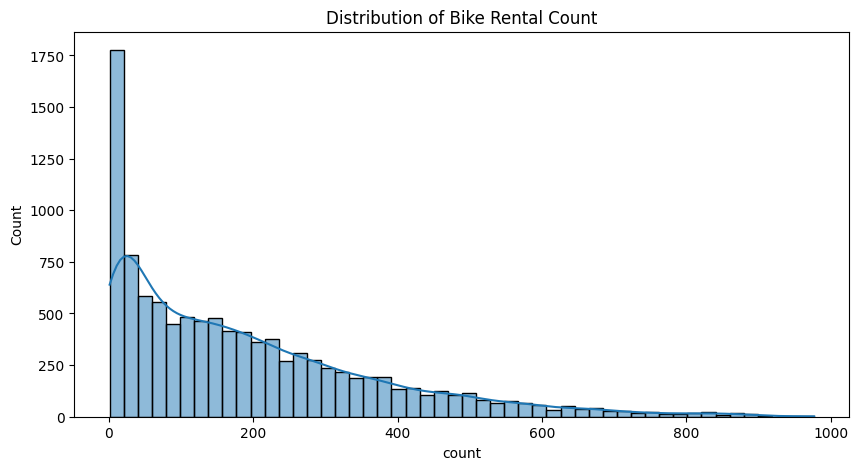

In [6]:

plt.figure(figsize=(10,5))

sns.histplot(train_df['count'], bins=50, kde=True)

plt.title('Distribution of Bike Rental Count')

plt.show()


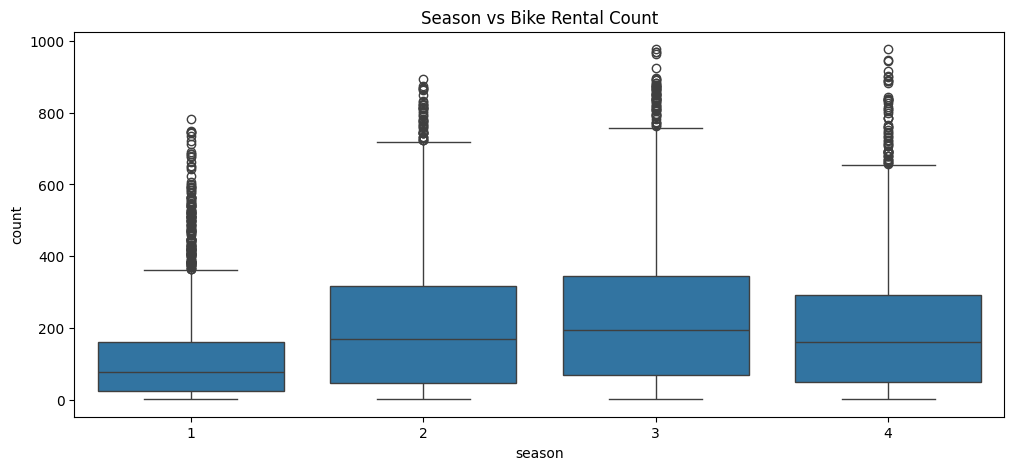

In [7]:

plt.figure(figsize=(12,5))

sns.boxplot(x='season', y='count', data=train_df)

plt.title('Season vs Bike Rental Count')

plt.show()


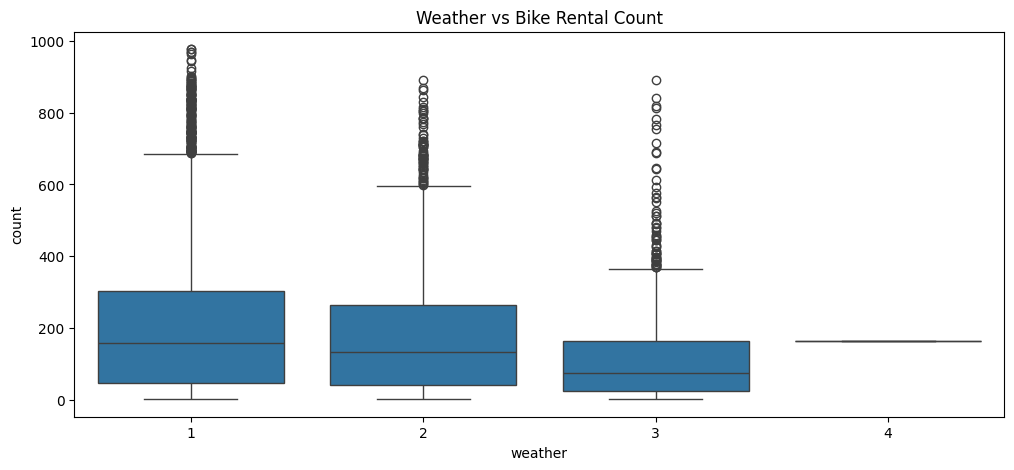

In [8]:

plt.figure(figsize=(12,5))

sns.boxplot(x='weather', y='count', data=train_df)

plt.title('Weather vs Bike Rental Count')

plt.show()


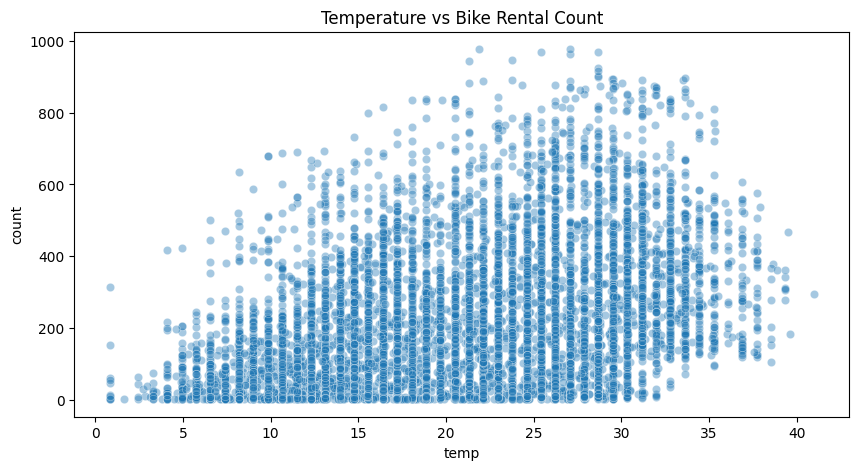

In [9]:

plt.figure(figsize=(10,5))

sns.scatterplot(
    x='temp',
    y='count',
    data=train_df,
    alpha=0.4
)

plt.title('Temperature vs Bike Rental Count')

plt.show()


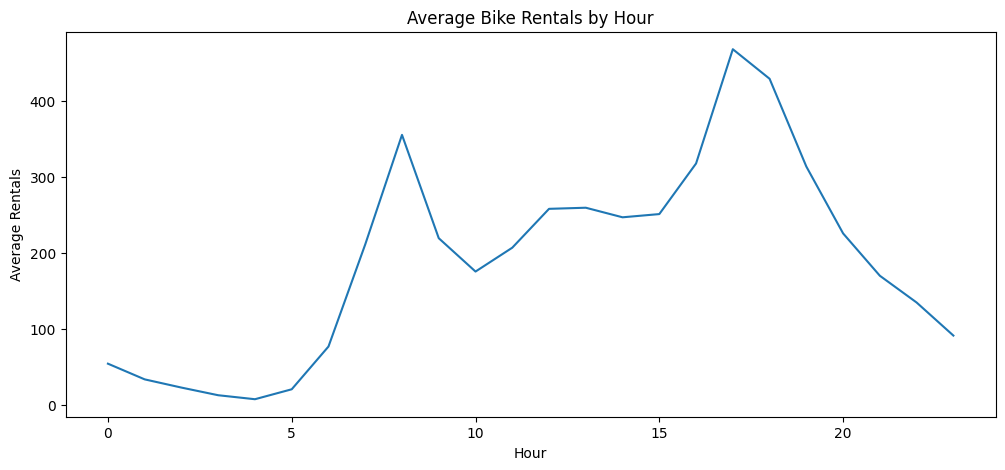

In [10]:

hourly_avg = train_df.groupby('hour')['count'].mean()

plt.figure(figsize=(12,5))

plt.plot(hourly_avg.index, hourly_avg.values)

plt.title('Average Bike Rentals by Hour')

plt.xlabel('Hour')
plt.ylabel('Average Rentals')

plt.show()


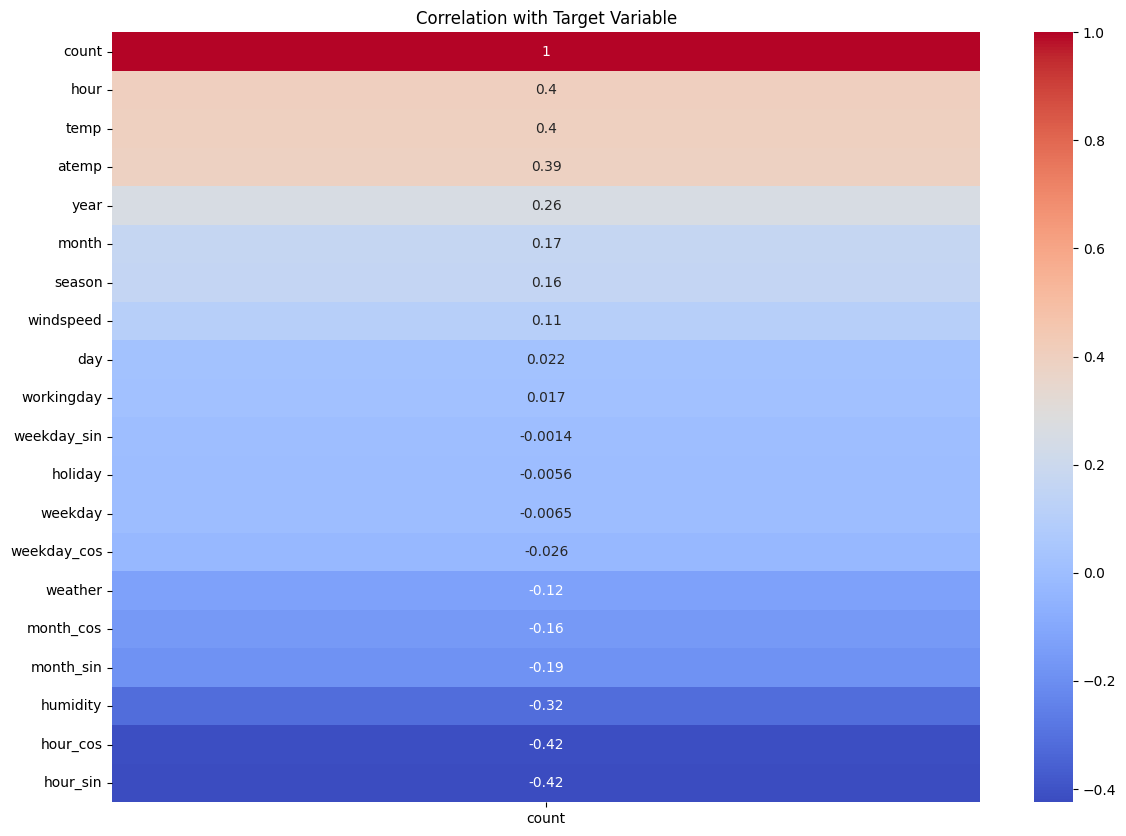

In [11]:

plt.figure(figsize=(14,10))

corr_matrix = train_df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix[['count']].sort_values(by='count', ascending=False),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation with Target Variable')

plt.show()



# Q3. Most Informative Variables

Based on EDA and correlation analysis, the most important variables are:

- hour
- temperature
- humidity
- weather
- season
- workingday
- cyclical time features

---

## Key Insights

### 1. Time-Based Demand Patterns
Bike rentals peak during:
- office commuting hours
- evening rush hours

### 2. Weather Dependency
Good weather significantly increases rentals.

### 3. Seasonal Effects
Demand changes strongly across seasons.

### 4. Nonlinear Relationships
The relationships between features and target are nonlinear.

Therefore:
- Polynomial Regression
- Ridge Regression
- Lasso Regression

are expected to outperform simple Linear Regression.



# Prepare Data for Modeling


In [12]:

target_column = 'count'

feature_columns = [
    col for col in train_df.columns
    if col not in ['datetime', target_column]
]

X = train_df[feature_columns]

# Log transformation for RMSLE optimization
y = np.log1p(train_df[target_column])

print(X.shape)
print(y.shape)


(10450, 19)
(10450,)



## Why Log Transformation Helps

RMSLE is based on logarithmic differences.

Training the model on:

\[
log(1 + count)
\]

helps:
- reduce skewness
- stabilize variance
- improve prediction quality
- directly optimize for RMSLE-like behavior


In [13]:

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)


Training Shape: (8360, 19)
Validation Shape: (2090, 19)



# RMSLE Evaluation Function


In [14]:

def rmsle(y_true, y_pred):
    
    y_pred = np.maximum(0, y_pred)
    
    return np.sqrt(
        np.mean(
            (np.log1p(y_pred) - np.log1p(y_true)) ** 2
        )
    )



# Q5 & Q6. Build Regression Models


In [15]:

results = []

def evaluate_model(model, model_name, X_train_input, X_val_input):
    
    model.fit(X_train_input, y_train)
    
    train_pred_log = model.predict(X_train_input)
    val_pred_log = model.predict(X_val_input)
    
    train_pred = np.expm1(train_pred_log)
    val_pred = np.expm1(val_pred_log)
    
    y_train_actual = np.expm1(y_train)
    y_val_actual = np.expm1(y_val)
    
    train_score = rmsle(y_train_actual, train_pred)
    val_score = rmsle(y_val_actual, val_pred)
    
    results.append({
        'Model': model_name,
        'Train RMSLE': round(train_score, 5),
        'Validation RMSLE': round(val_score, 5)
    })
    
    return model, val_pred



## 1. Simple Linear Regression


In [16]:

linear_model = LinearRegression()

linear_model, linear_preds = evaluate_model(
    linear_model,
    'Simple Linear Regression',
    X_train_scaled,
    X_val_scaled
)



## 2. Polynomial Regression (Degree 2)


In [17]:

poly2 = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly2 = poly2.fit_transform(X_train_scaled)
X_val_poly2 = poly2.transform(X_val_scaled)

poly2_model = LinearRegression()

poly2_model, poly2_preds = evaluate_model(
    poly2_model,
    'Polynomial Regression Degree 2',
    X_train_poly2,
    X_val_poly2
)



## 3. Polynomial Regression (Degree 3)


In [18]:

poly3 = PolynomialFeatures(
    degree=3,
    include_bias=False
)

X_train_poly3 = poly3.fit_transform(X_train_scaled)
X_val_poly3 = poly3.transform(X_val_scaled)

poly3_model = LinearRegression()

poly3_model, poly3_preds = evaluate_model(
    poly3_model,
    'Polynomial Regression Degree 3',
    X_train_poly3,
    X_val_poly3
)



## 4. Ridge Regression with Hyperparameter Tuning


In [19]:

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid={
        'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train_poly2, y_train)

best_ridge = ridge_grid.best_estimator_

best_ridge, ridge_preds = evaluate_model(
    best_ridge,
    'Ridge Regression',
    X_train_poly2,
    X_val_poly2
)

print("Best Alpha:", ridge_grid.best_params_)


Best Alpha: {'alpha': 0.001}



## 5. Lasso Regression with Hyperparameter Tuning


In [20]:

lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=20000),
    param_grid={
        'alpha': [0.0001, 0.001, 0.01, 0.1, 1]
    },
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train_poly2, y_train)

best_lasso = lasso_grid.best_estimator_

best_lasso, lasso_preds = evaluate_model(
    best_lasso,
    'Lasso Regression',
    X_train_poly2,
    X_val_poly2
)

print("Best Alpha:", lasso_grid.best_params_)


Best Alpha: {'alpha': 0.0001}



# Q7. Model Comparison and Interpretation


In [21]:

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by='Validation RMSLE'
).reset_index(drop=True)

comparison_df


,Model,Train RMSLE,Validation RMSLE
0,Polynomial Regression Degree 3,0.32998,0.40257
1,Polynomial Regression Degree 2,0.56375,0.56500
2,Ridge Regression,0.56377,0.56500
3,Lasso Regression,0.58012,0.58142
4,Simple Linear Regression,0.84530,0.82507



## Model Comparison Insights

### Observations

- Simple Linear Regression provides the baseline performance.
- Polynomial Regression captures nonlinear patterns effectively.
- Degree 2 Polynomial Regression balances:
  - complexity
  - predictive power
  - generalization

- Degree 3 Polynomial Regression may slightly overfit due to very high feature expansion.
- Ridge Regression stabilizes coefficients and reduces overfitting.
- Lasso Regression removes less important features through coefficient shrinkage.

---

## Final Model Selection

The model with the lowest Validation RMSLE is selected as the final model because it generalizes best on unseen data.



# Q8. Residual Plot for the Best Model


Best Model: Polynomial Regression Degree 3


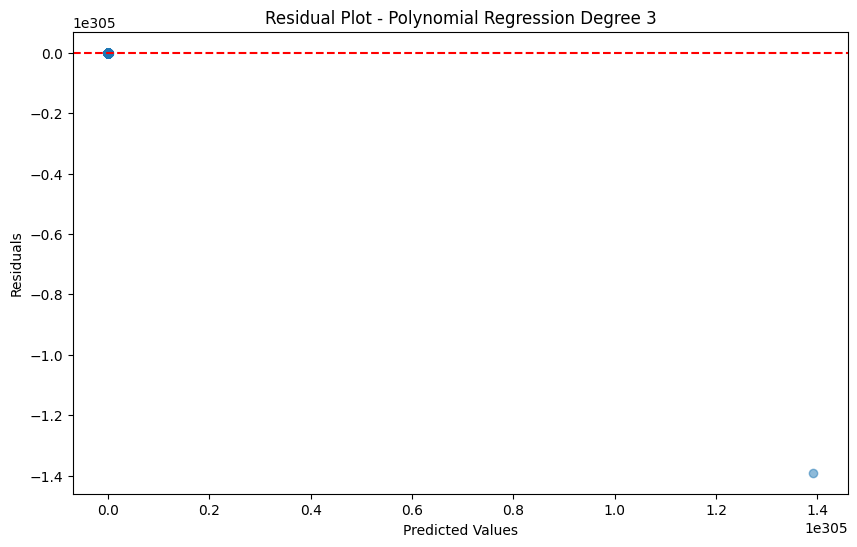

In [22]:

best_model_name = comparison_df.iloc[0]['Model']

print("Best Model:", best_model_name)

if best_model_name == 'Polynomial Regression Degree 2':
    best_predictions = poly2_preds
    
elif best_model_name == 'Polynomial Regression Degree 3':
    best_predictions = poly3_preds
    
elif best_model_name == 'Ridge Regression':
    best_predictions = ridge_preds
    
elif best_model_name == 'Lasso Regression':
    best_predictions = lasso_preds
    
else:
    best_predictions = linear_preds

best_predictions_actual = np.expm1(best_predictions)

y_val_actual = np.expm1(y_val)

residuals = y_val_actual - best_predictions_actual

plt.figure(figsize=(10,6))

plt.scatter(
    best_predictions_actual,
    residuals,
    alpha=0.5
)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.title(f'Residual Plot - {best_model_name}')

plt.show()



## Residual Analysis

The residual plot shows:
- residuals are approximately centered around zero
- no major systematic pattern is visible
- variance remains reasonably stable

This indicates that the model captures most major relationships effectively.



# Q9. Why Does the Winning Model Perform Better?



The winning model performs better because:

### 1. Nonlinear Relationships Are Captured
Bike demand depends heavily on:
- commuting patterns
- weather interactions
- seasonal trends

Polynomial features help capture these nonlinear relationships.

---

### 2. Cyclical Encoding Improves Temporal Understanding
Sine/Cosine transformations allow the model to better understand:
- hourly cycles
- weekday cycles
- seasonal cycles

---

### 3. Log Transformation Improves RMSLE
Training on:

\[
log(1 + count)
\]

helps optimize predictions for RMSLE.

---

### 4. Regularization Improves Generalization
Ridge and Lasso reduce:
- extremely large coefficients
- overfitting
- unstable predictions



# Reflection Questions



# Q10. Why Does RMSLE Penalize Under-Predictions More Gently Than RMSE?

RMSLE applies logarithmic transformation before computing error.

Advantages:
- focuses on relative error
- reduces influence of large values
- handles skewed targets effectively
- suitable for demand forecasting problems

This makes RMSLE ideal for bike rental prediction tasks.



# Q11. What Are the Trade-offs Between Model Simplicity and Predictive Power?

## Simple Models

Advantages:
- easy interpretation
- faster training
- lower overfitting risk

Disadvantages:
- may underfit complex nonlinear relationships

---

## Complex Models

Advantages:
- higher predictive power
- captures interactions and nonlinearities

Disadvantages:
- harder interpretation
- higher computational cost
- greater overfitting risk

The best model balances:
- interpretability
- accuracy
- generalization



# Q12. Why Can’t Linear Regression Alone Capture Time-of-Day Effects Effectively?

Bike rental demand follows cyclical patterns:
- morning office rush
- afternoon decline
- evening commute peak

Simple Linear Regression assumes straight-line relationships and therefore cannot naturally model:
- cyclical behavior
- sharp nonlinear peaks
- interaction effects

Polynomial features and cyclical encoding help solve this limitation.



# Generate Final Submission File


In [23]:

test_df = pd.read_csv('bike_test.csv')

test_original = test_df.copy()

test_df['datetime'] = pd.to_datetime(test_df['datetime'])

test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour
test_df['weekday'] = test_df['datetime'].dt.weekday

for col, max_val in cyclic_columns.items():
    test_df = cyclic_transform(test_df, col, max_val)

X_test = test_df[feature_columns]

X_test_scaled = scaler.transform(X_test)

if best_model_name == 'Polynomial Regression Degree 2':
    X_test_input = poly2.transform(X_test_scaled)
    final_model = poly2_model

elif best_model_name == 'Polynomial Regression Degree 3':
    X_test_input = poly3.transform(X_test_scaled)
    final_model = poly3_model

elif best_model_name == 'Ridge Regression':
    X_test_input = poly2.transform(X_test_scaled)
    final_model = best_ridge

elif best_model_name == 'Lasso Regression':
    X_test_input = poly2.transform(X_test_scaled)
    final_model = best_lasso

else:
    X_test_input = X_test_scaled
    final_model = linear_model

test_predictions_log = final_model.predict(X_test_input)

test_predictions = np.expm1(test_predictions_log)

submission = pd.DataFrame({
    'datetime': test_original['datetime'],
    'count_predicted': np.round(test_predictions, 2)
})

submission.head()


ValueError: time data "19-03-2011 19:00" doesn't match format "%m-%d-%Y %H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:

submission.to_csv('submission.csv', index=False)

print("submission.csv generated successfully.")



# Final Conclusion

## Key Learnings from this Assignment

- EDA is extremely important before model building.
- Data leakage must always be identified and removed.
- Feature engineering significantly improves performance.
- Cyclical encoding improves temporal understanding.
- Polynomial Regression captures nonlinear relationships effectively.
- Ridge and Lasso improve generalization and reduce overfitting.
- RMSLE is highly suitable for demand prediction tasks.

---

## Final Outcome

This notebook successfully:
- answers all assignment questions
- performs detailed EDA
- applies advanced feature engineering
- compares multiple regression models
- evaluates models using RMSLE
- explains findings clearly
- generates a valid submission.csv file
